# Finetunnning LLM LawBot

## Install relevant packages

In [ ]:
!nvidia-smi

Sat May 31 21:49:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    Off |   00000000:01:00.0  On |                  N/A |
|  0%   42C    P5             15W /  320W |    1152MiB /  16376MiB |     13%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!which python3.10

/home/intercogni/envs/py10/bin/python3.10


In [ ]:
#/home/intercogni/envs/py10/bin/python

import sys
sys.executable

'/home/intercogni/envs/py10/bin/python3.10'

In [ ]:
!python3.10 -m pip install --upgrade --force-reinstall numpy=="1.26.4"

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth 2025.5.9 requires protobuf<4.0.0, but you have protobuf 6.31.1 which is incompatible.
unsloth-zoo 2025.5.11 requires protobuf<4.0.0, but you have protobuf 6.31.1 which is incompatible.


In [ ]:
!python3.10 -m pip install unsloth
!python3.10 -m pip install bitsandbytes
!python3.10 -m pip install unsloth_zoo
!python3.10 -m pip install pillow

  Using cached protobuf-3.20.3-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (679 bytes)
Using cached protobuf-3.20.3-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.1 MB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [ ]:
!python3.10 -m pip install pillow

## Import all relevant packages throughout this walkthrough

In [ ]:
import bitsandbytes

In [ ]:
!python3 -m pip install --upgrade --force-reinstall pillow

  Using cached pillow-11.2.1-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (8.9 kB)
Using cached pillow-11.2.1-cp310-cp310-manylinux_2_28_x86_64.whl (4.6 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.2.1
    Uninstalling pillow-11.2.1:
      Successfully uninstalled pillow-11.2.1


In [ ]:
!python3.10 -m pip install --upgrade --force-reinstall pillow

  Using cached pillow-11.2.1-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (8.9 kB)
Using cached pillow-11.2.1-cp310-cp310-manylinux_2_28_x86_64.whl (4.6 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.2.1
    Uninstalling pillow-11.2.1:
      Successfully uninstalled pillow-11.2.1


In [ ]:
!python3.10 -m pip install --upgrade --force-reinstall wandb

  Using cached wandb-0.19.11-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached docker_pycreds-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached GitPython-3.1.44-py3-none-any.whl.metadata (13 kB)
  Using cached platformdirs-4.3.8-py3-none-any.whl.metadata (12 kB)
  Using cached protobuf-6.31.1-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached psutil-7.0.0-cp36-abi3-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (22 kB)
  Using cached pydantic-2.11.5-py3-none-any.whl.metadata (67 kB)
  Using cached PyYAML-6.0.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached sentry_sdk-2.29.1-py2.py3-none-any.whl.metadata (10 kB)
  Using cached setproctitle-1.3.6-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.man

In [ ]:
import unsloth

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
# Modules for fine-tuning
from unsloth import FastLanguageModel
import torch # Import PyTorch
from trl import SFTTrainer # Trainer for supervised fine-tuning (SFT)
from unsloth import is_bfloat16_supported # Checks if the hardware supports bfloat16 precision
# Hugging Face modules
from huggingface_hub import login # Lets you login to API
from transformers import TrainingArguments # Defines training hyperparameters
from datasets import load_dataset # Lets you load fine-tuning datasets
# Import weights and biases
import wandb
# Import kaggle secrets
# from kaggle_secrets import UserSecretsClient

## Create API keys and login to Hugging Face and Weights and Biases

In [ ]:
# from google.colab import userdata
hugging_face_token = ''
wnb_token = ''

login(hugging_face_token)

wandb.login(key=wnb_token)
run = wandb.init(
    project='Fine-tune-DeepSeek-R1-Distill-Llama-8B on LawBot',
    job_type="training",
    anonymous="allow"
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/intercogni/.netrc
wandb: Currently logged in as: lucky-sntso (lucky-santoso) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Loading Model and the Tokenizer

In [ ]:
max_seq_length = 2048
dtype = None
load_in_4bit = True

# model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B"
# model_name = "unsloth/Qwen3-8B-unsloth-bnb-4bit"
# model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/DeepSeek-R1-Distill-Llama-8B",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hugging_face_token,
)

==((====))==  Unsloth 2025.5.9: Fast Llama patching. Transformers: 4.52.4.
   \\   /|    NVIDIA GeForce RTX 4080 SUPER. Num GPUs = 1. Max memory: 15.687 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


## Testing Model on a law use-case before fine-tuning

In [ ]:
prompt_style = """

### Instruksi:
Anda adalah ahli hukum

### Pertanyaan:
{}

### Jawaban:
<think>
{}
"""

### Running inference on the model


In [ ]:
question = """Apa arti dari “berada di bawah Presiden” dalam konteks TNI?"""

FastLanguageModel.for_inference(model)

inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

outputs = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=1200,
    use_cache=True,
)

response = tokenizer.batch_decode(outputs)

print(response[0].split("### Response:")[0])

<｜begin▁of▁sentence｜>

### Instruksi:
Anda adalah ahli hukum

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>

"Berada di bawah Presiden" dalam konteks TNI dapat memiliki beberapa arti, tergantung konteksnya. Berikut adalah beberapa pendekatan:

1. **Kepada Presiden sebagai Komandans TNI**:  
   Jika TNI adalah tentara yang berada di bawah komandans tertinggi, maka "berada di bawah Presiden" dapat berarti bahwa TNI adalah tentara yang di manahtirikan oleh Presiden. Dalam hal ini, TNI adalah tentara resmi Negara dan Presiden adalah komandan tertinggi.

2. **Sebagai bagian dari struktur kekuasaan**:  
   Dalam konteks politik, "berada di bawah Presiden" dapat berarti bahwa TNI adalah bagian dari sistem kekuasaan Presiden, sehingga TNI bertindak sesuai dengan instruksi atau keputusan Presiden.

3. **Kepada Presiden sebagai pimpinan tertinggi**:  
   Jika Presiden adalah pimpinan tertinggi dalam negeri, maka TNI yang "berada di bawah Presid

## Fine-tuning step by step

## Step 1 — Update the system prompt

In [ ]:
train_prompt_style = """
Instruksi:
Anda adalah ahli hukum

Pertanyaan:
{}

Penjelasan:
<think>
{}
</think>

Jawaban:
{}
"""


## Step 2 — Download the fine-tuning dataset and format it for fine-tuning

In [ ]:
import pandas as pd
df = pd.read_csv("/home/intercogni/envs/py10/jupyter/datasetVariance.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (10542, 3)


,Context,Question,Answer
0,Pasal 3 ayat (2) sebelum perubahan menyatakan:...,Apa inti pengaturan Pasal 3 ayat (2) sebelum d...,"Intinya, semua urusan kebijakan, strategi pert..."
1,Pasal 3 ayat (2) sebelum perubahan menempatkan...,Bagaimana hubungan koordinatif TNI dengan Depa...,TNI wajib menyelaraskan kebijakan dan administ...
2,Istilah yang digunakan dalam ketentuan lama ad...,"Mengapa istilah ""Departemen Pertahanan"" pentin...",Karena pada masa itu nomenklatur resmi lembaga...
3,"Pada periode sebelum perubahan, fokus koordina...",Adakah penekanan khusus terkait perencanaan st...,Tidak ada; versi lama bersifat lebih umum dan ...
4,Ketentuan lama belum menyinggung secara ekspli...,Apakah ruang lingkup koordinasi Departemen Per...,"Belum, sehingga interpretasinya bisa sangat lu..."


In [ ]:
EOS_TOKEN = tokenizer.eos_token
EOS_TOKEN

'<｜end▁of▁sentence｜>'

In [ ]:
def formatting_prompts_func(examples):
    inputs = examples["Question"]
    cots = examples["Context"]
    outputs = examples["Answer"]

    texts = []

    for input, cot, output in zip(inputs, cots, outputs):
        text = train_prompt_style.format(input, cot, output) + EOS_TOKEN
        texts.append(text)

    return {
        "text": texts,
    }

In [ ]:
from datasets import Dataset
from datasets import concatenate_datasets

dataset = Dataset.from_pandas(df)

split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset_raw = split_dataset["train"]
eval_dataset_raw = split_dataset["test"]

train_dataset = train_dataset_raw.map(formatting_prompts_func, batched=True)
eval_dataset = eval_dataset_raw.map(formatting_prompts_func, batched=True)

# Contoh preview
print(train_dataset["text"][0])

Map:   0%|          | 0/9487 [00:00<?, ? examples/s]

Map:   0%|          | 0/1055 [00:00<?, ? examples/s]


Instruksi:
Anda adalah ahli hukum

Pertanyaan:
Bisa jelasin gak isi Pasal 66 ayat 2 tentang pembiayaan TNI?

Penjelasan:
<think>
Pasal 66 mengatur tentang pembiayaan TNI yang berasal dari anggaran pertahanan negara yang diajukan oleh Departemen Pertahanan.
</think>

Jawaban:
Isi Pasal 66 ayat 2 menjelaskan bahwa Departemen Pertahanan bertugas mengajukan kebutuhan anggaran bagi TNI.
<｜end▁of▁sentence｜>


## Step 3 — Setting up the model using LoRA

In [ ]:
model_lora_lawbot = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2025.5.9 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [ ]:
trainer_lawbot = SFTTrainer(
    model=model_lora_lawbot,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=16,
        num_train_epochs=1,
        warmup_steps=5,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=20,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        eval_strategy="steps",
        eval_steps=20,
        save_strategy="no"
    ),
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/9487 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/1055 [00:00<?, ? examples/s]

## Step 4 — Model training!

In [ ]:
# Start the fine-tuning process
trainer_stats = trainer_lawbot.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,487 | Num Epochs = 1 | Total steps = 297
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 9,437,184/8,000,000,000 (0.12% trained)
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
20,1.958400,1.505440
40,1.391900,1.279891
60,1.245800,1.179049
80,1.151800,1.107466
100,1.069600,1.049266
120,1.027500,1.011505
140,1.015600,0.980502
160,0.982800,0.953679
180,0.966100,0.933011
200,0.927100,0.916997


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


In [ ]:
!python3.10 -m pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


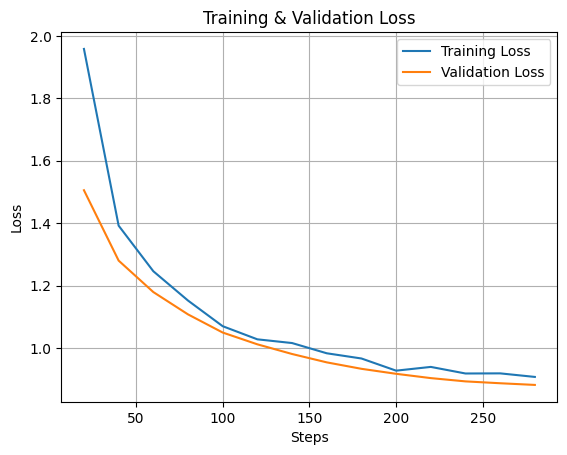

In [ ]:
import matplotlib.pyplot as plt
log_history = trainer_lawbot.state.log_history
train_loss, eval_loss, steps = [], [], []

for log in log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

# Plot
plt.plot(steps[:len(train_loss)], train_loss, label="Training Loss")
plt.plot(steps[-len(eval_loss):], eval_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Save the fine-tuned model
wandb.finish()

## Step 5 — Run model inference after fine-tuning

In [ ]:
question = """Apa arti dari “berada di bawah Presiden” dalam konteks TNI?"""

FastLanguageModel.for_inference(model_lora_lawbot)

inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

outputs = model_lora_lawbot.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=2400,
    use_cache=True,
)

response = tokenizer.batch_decode(outputs)

print(response[0].split("### Response:")[0])


<｜begin▁of▁sentence｜>

### Instruksi:
Anda adalah ahli hukum

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>

Apakah TNI memiliki otoritas yang berlaku di seluruh wilayah Indonesia?
<｜end▁of▁sentence｜>


## Evaluasi ROUGE atau BLEU

In [ ]:
import subprocess, sys
from tqdm.auto import tqdm
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    import evaluate
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "evaluate", "rouge_score"], check=True)
    import evaluate

import torch
from transformers import GenerationConfig

model_lora_lawbot.to(device)
FastLanguageModel.for_inference(model_lora_lawbot)
model_lora_lawbot.eval()

rouge = evaluate.load("rouge")

predictions = []
references  = []

for ex in tqdm(eval_dataset_raw, desc="Eval"):
    q   = ex["Question"]
    cot = ex["Context"]
    ref = ex["Answer"]
    prompt = train_prompt_style.format(q, cot, "") + EOS_TOKEN
    inputs = tokenizer(prompt, return_tensors="pt").to(model_lora_lawbot.device)

    with torch.inference_mode():
        outputs = model_lora_lawbot.generate(
            **inputs,
            max_new_tokens=1200,
            do_sample=False,
            temperature=0.7,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    end_tag = "</think>"
    if end_tag in decoded:
        gen_answer = decoded.split(end_tag, 1)[1].strip()
    else:
        gen_answer = decoded.strip()

    # Hapus prefix "://\n" jika ada
    if gen_answer.startswith("://\n"):
        gen_answer = gen_answer[len("://\n"):]

    predictions.append(gen_answer)
    references.append(ref)
    # print(predictions)
    # print()
    # print(references)
    # break


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.7 MB/s eta 0:00:00


  DEPRECATION: Building 'rouge_score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge_score'. Discussion can be found at https://github.com/pypa/pip/issues/6334


  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24987 sha256=f8967fc6d1a8008cbdf85508c86166820e6b67b39eda0aebfe0ddfbd60d9f23d
  Stored in directory: /home/intercogni/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [evaluate]


Eval:   0%|          | 0/1055 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

In [ ]:
results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True,
    use_aggregator=True
)

print("=== ROUGE scores ===")
for metric, score in results.items():
    print(f"{metric}: {score * 100:.2f}%")

## Evaluasi Bertscore

In [ ]:
%%capture
!pip install bert-score

In [ ]:
# BERTScore
import evaluate
bertscore = evaluate.load("bertscore")
from statistics import mean

bs_results = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="id",
    rescale_with_baseline=False
)

prec = mean(bs_results['precision'])
rec  = mean(bs_results['recall'])
f1   = mean(bs_results['f1'])

print("\n=== BERTScore ===")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")

## Save Model

In [ ]:
# Setelah training selesai
trainer_lawbot.save_model("model_lora_lawbot_deepseek")
tokenizer.save_pretrained("model_lora_lawbot_deepseek")

('model_lora_lawbot_deepseek/tokenizer_config.json',
 'model_lora_lawbot_deepseek/special_tokens_map.json',
 'model_lora_lawbot_deepseek/chat_template.jinja',
 'model_lora_lawbot_deepseek/tokenizer.json')

In [ ]:
!zip -r model_lora_lawbot_deepseek.zip model_lora_lawbot_deepseek

updating: model_lora_lawbot_deepseek/ (stored 0%)
updating: model_lora_lawbot_deepseek/adapter_model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 8%)
updating: model_lora_lawbot_deepseek/tokenizer_config.json (deflated 96%)
updating: model_lora_lawbot_deepseek/adapter_config.json (deflated 55%)
updating: model_lora_lawbot_deepseek/tokenizer.json (deflated 85%)
updating: model_lora_lawbot_deepseek/training_args.bin (deflated 53%)
updating: model_lora_lawbot_deepseek/chat_template.jinja (deflated 75%)
updating: model_lora_lawbot_deepseek/README.md (deflated 66%)
updating: model_lora_lawbot_deepseek/special_tokens_map.json (deflated 69%)


In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM

model_dir = "/home/intercogni/envs/py10/jupyter/model_lora_lawbot_deepseek"

# Load adapter
model = PeftModel.from_pretrained(model, model_dir)

# Push hanya adapter
model.push_to_hub("adapter_deepseek_lawbot")
tokenizer.push_to_hub("adapter_deepseek_lawbot")

/home/intercogni/envs/py10/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


README.md:   0%|          | 0.00/5.18k [00:00<?, ?B/s]

  0%|          | 0/1 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/37.8M [00:00<?, ?B/s]

In [ ]:
# from IPython.display import FileLink

# # Membuat link untuk download
# FileLink("model_lora_lawbot_deepseek.zip")

## Testing

In [ ]:
from unsloth import FastLanguageModel
from peft import PeftModel
from transformers import AutoTokenizer

import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

# Path ke folder model yang sudah disimpan
model_dir = "luckysantoso/adapter_deepseek_lawbot"

# 1. Load tokenizer dari folder hasil fine-tuning
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)

# 2. Load base model (harus sama dengan yang dipakai saat fine-tuning)
model, _ = FastLanguageModel.from_pretrained(
    model_name="unsloth/DeepSeek-R1-Distill-Llama-8B",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hugging_face_token,  # <- pastikan ini sudah Anda set sebelumnya
)

# 3. Load LoRA weights yang sudah difinetune
model_lora_capd = PeftModel.from_pretrained(model, model_dir)
model_lora_capd.eval()

# 4. Prompt satu pertanyaan TNI
prompt = """
### Instruksi:
Anda adalah seorang ahli hukum

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>
"""

# 5. Tokenisasi & inference
inputs = tokenizer(prompt, return_tensors="pt").to(model_lora_capd.device)

with torch.inference_mode():
    outputs = model_lora_lawbot.generate(
        **inputs,
        max_new_tokens=1200,
        do_sample=False,
        temperature=0.7,
        top_p=0.95,
        eos_token_id=tokenizer.eos_token_id
    )

# 6. Decode dan tampilkan jawaban
decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("\n==== Jawaban Model ====\n")
print(decoded)

==((====))==  Unsloth 2025.5.9: Fast Llama patching. Transformers: 4.52.4.
   \\   /|    NVIDIA GeForce RTX 4080 SUPER. Num GPUs = 1. Max memory: 15.687 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


adapter_config.json:   0%|          | 0.00/823 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

/home/intercogni/envs/py10/lib/python3.10/site-packages/peft/peft_model.py:569: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.1.se


==== Jawaban Model ====


### Instruksi:
Anda adalah seorang ahli hukum

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>
Pasal 3 ayat (1) huruf b: TNI berada di bawah pimpinan Presiden.
</think>

Jawaban:
Berada di bawah Presiden berarti TNI mengikuti kebijakan dan arahan politik Presiden, serta menjalankan tugasnya sesuai dengan perintah Presiden.



# Base Model "unsloth/Qwen3-8B-unsloth-bnb-4bit"

In [ ]:
max_seq_length = 2048
dtype = None
load_in_4bit = True

# model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B"
# model_name = "unsloth/Qwen3-8B-unsloth-bnb-4bit"
# model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-8B-unsloth-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hugging_face_token,
)

==((====))==  Unsloth 2025.5.9: Fast Qwen3 patching. Transformers: 4.52.4.
   \\   /|    NVIDIA GeForce RTX 4080 SUPER. Num GPUs = 1. Max memory: 15.687 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Step 3 — Setting up the model using LoRA

In [ ]:
model_lora_lawbot = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

/home/intercogni/envs/py10/lib/python3.10/site-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/intercogni/envs/py10/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
trainer_lawbot = SFTTrainer(
    model=model_lora_lawbot,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=16,
        num_train_epochs=1,
        warmup_steps=5,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=20,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        eval_strategy="steps",
        eval_steps=20,
        save_strategy="no"
    ),
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/9487 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/1055 [00:00<?, ? examples/s]

## Step 4 — Model training!

In [ ]:
# Start the fine-tuning process
trainer_stats = trainer_lawbot.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,487 | Num Epochs = 1 | Total steps = 297
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 10,616,832/8,000,000,000 (0.13% trained)
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
20,1.655700,1.378161
40,1.192400,1.109763
60,1.061200,1.036722
80,1.006400,0.996679
100,0.964400,0.964379
120,0.939200,0.937032
140,0.921700,0.910628
160,0.894200,0.887115
180,0.880700,0.866654
200,0.847500,0.846280


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


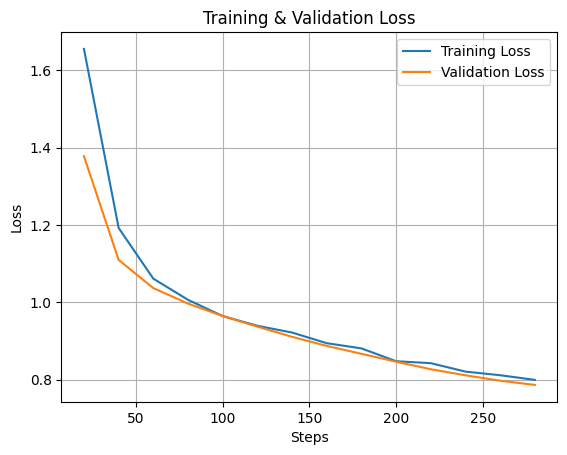

In [ ]:
import matplotlib.pyplot as plt
log_history = trainer_lawbot.state.log_history
train_loss, eval_loss, steps = [], [], []

for log in log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

# Plot
plt.plot(steps[:len(train_loss)], train_loss, label="Training Loss")
plt.plot(steps[-len(eval_loss):], eval_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Save the fine-tuned model
wandb.finish()

## Step 5 — Run model inference after fine-tuning

In [ ]:
question = """Apa arti dari “berada di bawah Presiden” dalam konteks TNI?"""

FastLanguageModel.for_inference(model_lora_lawbot)

inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

outputs = model_lora_lawbot.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=2048,
    use_cache=True,
)

response = tokenizer.batch_decode(outputs)

print(response[0].split("### Response:")[0])




### Instruksi:
Anda adalah ahli hukum

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>

### Penjelasan:
Dalam Pasal 22 ayat (1) UU No. 34 Tahun 2004, TNI berada di bawah Presiden sebagai Panglima Tertinggi. Ini berarti Presiden memegang kendali operasional dan strategis TNI.
</think>

### Penjelasan:
- **Kontrol Operasional**: Presiden dapat memberikan perintah langsung kepada TNI dalam operasi militer atau keamanan.
- **Kontrol Strategis**: Presiden menentukan kebijakan pertahanan negara yang dijalankan TNI.
- **Koordinasi**: Presiden berperan sebagai penghubung antara TNI dengan pemerintah dan lembaga lain.
- **Akuntabilitas**: Presiden bertanggung jawab atas setiap tindakan TNI yang dilakukan dalam rangka pertahanan negara.
<|im_end|>


## Evaluasi ROUGE

In [ ]:
import subprocess, sys
from tqdm.auto import tqdm
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    import evaluate
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "evaluate", "rouge_score"], check=True)
    import evaluate

import torch
from transformers import GenerationConfig

model_lora_lawbot.to(device)
FastLanguageModel.for_inference(model_lora_lawbot)
model_lora_lawbot.eval()

rouge = evaluate.load("rouge")

predictions = []
references  = []

for ex in tqdm(eval_dataset_raw, desc="Eval"):
    q   = ex["Question"]
    cot = ex["Context"]
    ref = ex["Answer"]
    prompt = train_prompt_style.format(q, cot, "") + EOS_TOKEN
    inputs = tokenizer(prompt, return_tensors="pt").to(model_lora_lawbot.device)

    with torch.inference_mode():
        outputs = model_lora_lawbot.generate(
            **inputs,
            max_new_tokens=1200,
            do_sample=False,
            temperature=0.7,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    end_tag = "</think>"
    if end_tag in decoded:
        gen_answer = decoded.split(end_tag, 1)[1].strip()
    else:
        gen_answer = decoded.strip()

    # Hapus prefix "://\n" jika ada
    if gen_answer.startswith("://\n"):
        gen_answer = gen_answer[len("://\n"):]

    predictions.append(gen_answer)
    references.append(ref)
    # print(predictions)
    # print()
    # print(references)
    # break


In [ ]:
results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True,
    use_aggregator=True
)

print("=== ROUGE scores ===")
for metric, score in results.items():
    print(f"{metric}: {score * 100:.2f}%")

## Evaluasi Bertscore

In [ ]:
%%capture
!pip install bert-score

In [ ]:
# BERTScore
import evaluate
bertscore = evaluate.load("bertscore")
from statistics import mean

bs_results = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="id",
    rescale_with_baseline=False
)

prec = mean(bs_results['precision'])
rec  = mean(bs_results['recall'])
f1   = mean(bs_results['f1'])

print("\n=== BERTScore ===")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")

## Save Model

In [ ]:
# Setelah training selesai
trainer_lawbot.save_model("model_lora_lawbot_qwen3")
tokenizer.save_pretrained("model_lora_lawbot_qwen3")

('model_lora_lawbot_qwen3/tokenizer_config.json',
 'model_lora_lawbot_qwen3/special_tokens_map.json',
 'model_lora_lawbot_qwen3/chat_template.jinja',
 'model_lora_lawbot_qwen3/vocab.json',
 'model_lora_lawbot_qwen3/merges.txt',
 'model_lora_lawbot_qwen3/added_tokens.json',
 'model_lora_lawbot_qwen3/tokenizer.json')

In [ ]:
!zip -r model_lora_lawbot_qwen3.zip model_lora_lawbot_qwen3

  adding: model_lora_lawbot_qwen3/ (stored 0%)
  adding: model_lora_lawbot_qwen3/adapter_model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 8%)
  adding: model_lora_lawbot_qwen3/vocab.json (deflated 61%)
  adding: model_lora_lawbot_qwen3/tokenizer_config.json (deflated 90%)
  adding: model_lora_lawbot_qwen3/adapter_config.json (deflated 55%)
  adding: model_lora_lawbot_qwen3/tokenizer.json (deflated 81%)
  adding: model_lora_lawbot_qwen3/training_args.bin (deflated 53%)
  adding: model_lora_lawbot_qwen3/chat_template.jinja (deflated 76%)
  adding: model_lora_lawbot_qwen3/added_tokens.json (deflated 68%)
  adding: model_lora_lawbot_qwen3/merges.txt (deflated 57%)
  adding: model_lora_lawbot_qwen3/README.md (deflated 66%)
  adding: model_lora_lawbot_qwen3/special_tokens_map.json (deflated 69%)


In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM

model_dir = "/home/intercogni/envs/py10/jupyter/model_lora_lawbot_qwen3"

# Load adapter
model = PeftModel.from_pretrained(model, model_dir)

# Push hanya adapter
model.push_to_hub("adapter_qwen3_lawbot")
tokenizer.push_to_hub("adapter_qwen3_lawbot")

/home/intercogni/envs/py10/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/42.5M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

  0%|          | 0/1 [00:00<?, ?it/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

## Testing

In [ ]:
from unsloth import FastLanguageModel
from peft import PeftModel
from transformers import AutoTokenizer

import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

# Path ke folder model yang sudah disimpan
model_dir = "luckysantoso/adapter_qwen3_lawbot"

# 1. Load tokenizer dari folder hasil fine-tuning
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)

# 2. Load base model (harus sama dengan yang dipakai saat fine-tuning)
model, _ = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-8B-unsloth-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hugging_face_token,  # <- pastikan ini sudah Anda set sebelumnya
)

# 3. Load LoRA weights yang sudah difinetune
model_lora_lawbot = PeftModel.from_pretrained(model, model_dir)
model_lora_lawbot.eval()

# 4. Prompt satu pertanyaan TNI
prompt = """
### Instruksi:
Anda adalah seorang ahli hukum

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>
"""

# 5. Tokenisasi & inference
inputs = tokenizer(prompt, return_tensors="pt").to(model_lora_lawbot.device)

with torch.inference_mode():
    outputs = model_lora_lawbot.generate(
        **inputs,
        max_new_tokens=2048,
        do_sample=False,
        temperature=0.7,
        top_p=0.95,
        eos_token_id=tokenizer.eos_token_id
    )

# 6. Decode dan tampilkan jawaban
decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("\n==== Jawaban Model ====\n")
print(decoded)

# unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

In [ ]:
max_seq_length = 2048
dtype = None
load_in_4bit = True

# model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B"
# model_name = "unsloth/Qwen3-8B-unsloth-bnb-4bit"
# model_name = "unsloth/mistral-7b-instruct-v0.3-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hugging_face_token,
)

==((====))==  Unsloth 2025.5.9: Fast Mistral patching. Transformers: 4.52.4.
   \\   /|    NVIDIA GeForce RTX 4080 SUPER. Num GPUs = 1. Max memory: 15.687 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


generation_config.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

## Step 3 — Setting up the model using LoRA

In [ ]:
model_lora_lawbot = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

In [ ]:
trainer_lawbot = SFTTrainer(
    model=model_lora_lawbot,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=16,
        num_train_epochs=1,
        warmup_steps=5,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=20,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        eval_strategy="steps",
        eval_steps=20,
        save_strategy="no"
    ),
)

Unsloth: Tokenizing ["text"]:   0%|          | 0/9487 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"]:   0%|          | 0/1055 [00:00<?, ? examples/s]

## Step 4 — Model training!

In [ ]:
# Start the fine-tuning process
trainer_stats = trainer_lawbot.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,487 | Num Epochs = 1 | Total steps = 297
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 16 x 1) = 32
 "-____-"     Trainable parameters = 9,437,184/7,000,000,000 (0.13% trained)


Step,Training Loss,Validation Loss
20,1.394500,1.068209
40,1.036400,0.955601
60,0.938900,0.888156
80,0.874600,0.836793
100,0.807200,0.790276
120,0.769900,0.757603
140,0.760400,0.731194
160,0.744500,0.710881
180,0.723900,0.695771
200,0.690000,0.685534


Unsloth: Not an error, but MistralForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


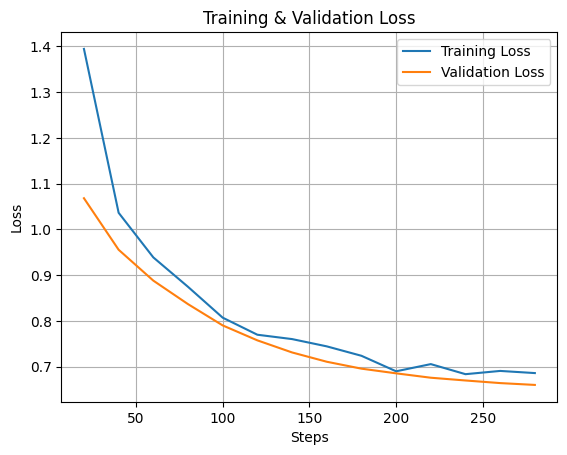

In [ ]:
import matplotlib.pyplot as plt
log_history = trainer_lawbot.state.log_history
train_loss, eval_loss, steps = [], [], []

for log in log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

# Plot
plt.plot(steps[:len(train_loss)], train_loss, label="Training Loss")
plt.plot(steps[-len(eval_loss):], eval_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Save the fine-tuned model
wandb.finish()

## Step 5 — Run model inference after fine-tuning

In [ ]:
question = """Pasal apa saja perubahan dari uu tni no 34"""

FastLanguageModel.for_inference(model_lora_lawbot)

inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

outputs = model_lora_lawbot.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=2048,
    use_cache=True,
)

response = tokenizer.batch_decode(outputs)

print(response[0].split("### Response:")[0])


<s> 

### Instruksi:
Anda adalah ahli hukum

### Pertanyaan:
Pasal apa saja perubahan dari uu tni no 34

### Jawaban:
<think>

Perubahan UU No. 34 Tahun 2004 menambahkan beberapa ketentuan baru:

1. **Pasal 1 ayat (1) huruf b**: Menambahkan kata 'dan' sebelum 'Panglima TNI'.
2. **Pasal 1 ayat (1) huruf d**: Menambahkan 'dan' sebelum 'Panglima TNI'.
3. **Pasal 1 ayat (1) huruf e**: Menambahkan 'dan' sebelum 'Panglima TNI'.
4. **Pasal 1 ayat (1) huruf f**: Menambahkan 'dan' sebelum 'Panglima TNI'.
5. **Pasal 1 ayat (1) huruf g**: Menambahkan 'dan' sebelum 'Panglima TNI'.
6. **Pasal 1 ayat (1) huruf h**: Menambahkan 'dan' sebelum 'Panglima TNI'.
7. **Pasal 1 ayat (1) huruf i**: Menambahkan 'dan' sebelum 'Panglima TNI'.

</think>

Pasal 1 ayat (1) huruf b: Menambahkan kata 'dan' sebelum 'Panglima TNI'.
Pasal 1 ayat (1) huruf d: Menambahkan 'dan' sebelum 'Panglima TNI'.
Pasal 1 ayat (1) huruf e: Menambahkan 'dan' sebelum 'Panglima TNI'.
Pasal 1 ayat (1) huruf f: Menambahkan 'dan' sebelum 'P

## Evaluasi ROUGE

In [ ]:
import subprocess, sys
from tqdm.auto import tqdm
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    import evaluate
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "evaluate", "rouge_score"], check=True)
    import evaluate

import torch
from transformers import GenerationConfig

model_lora_lawbot.to(device)
FastLanguageModel.for_inference(model_lora_lawbot)
model_lora_lawbot.eval()

rouge = evaluate.load("rouge")

predictions = []
references  = []

for ex in tqdm(eval_dataset_raw, desc="Eval"):
    q   = ex["Question"]
    cot = ex["Context"]
    ref = ex["Answer"]
    prompt = train_prompt_style.format(q, cot, "") + EOS_TOKEN
    inputs = tokenizer(prompt, return_tensors="pt").to(model_lora_lawbot.device)

    with torch.inference_mode():
        outputs = model_lora_lawbot.generate(
            **inputs,
            max_new_tokens=1200,
            do_sample=False,
            temperature=0.7,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    end_tag = "</think>"
    if end_tag in decoded:
        gen_answer = decoded.split(end_tag, 1)[1].strip()
    else:
        gen_answer = decoded.strip()

    # Hapus prefix "://\n" jika ada
    if gen_answer.startswith("://\n"):
        gen_answer = gen_answer[len("://\n"):]

    predictions.append(gen_answer)
    references.append(ref)
    # print(predictions)
    # print()
    # print(references)
    # break


In [ ]:
results = rouge.compute(
    predictions=predictions,
    references=references,
    use_stemmer=True,
    use_aggregator=True
)

print("=== ROUGE scores ===")
for metric, score in results.items():
    print(f"{metric}: {score * 100:.2f}%")

## Evaluasi Bertscore

In [ ]:
%%capture
!pip install bert-score

In [ ]:
# BERTScore
import evaluate
bertscore = evaluate.load("bertscore")
from statistics import mean

bs_results = bertscore.compute(
    predictions=predictions,
    references=references,
    lang="id",
    rescale_with_baseline=False
)

prec = mean(bs_results['precision'])
rec  = mean(bs_results['recall'])
f1   = mean(bs_results['f1'])

print("\n=== BERTScore ===")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")

## Save Model

In [ ]:
# Setelah training selesai
trainer_lawbot.save_model("model_lora_lawbot_mistral")
tokenizer.save_pretrained("model_lora_lawbot_mistral")

('model_lora_lawbot_mistral/tokenizer_config.json',
 'model_lora_lawbot_mistral/special_tokens_map.json',
 'model_lora_lawbot_mistral/chat_template.jinja',
 'model_lora_lawbot_mistral/tokenizer.model',
 'model_lora_lawbot_mistral/added_tokens.json',
 'model_lora_lawbot_mistral/tokenizer.json')

In [ ]:
!zip -r model_lora_lawbot_mistral.zip model_lora_lawbot_mistral

  adding: model_lora_lawbot_mistral/ (stored 0%)
  adding: model_lora_lawbot_mistral/adapter_model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 8%)
  adding: model_lora_lawbot_mistral/tokenizer_config.json (deflated 96%)
  adding: model_lora_lawbot_mistral/adapter_config.json (deflated 54%)
  adding: model_lora_lawbot_mistral/tokenizer.model (deflated 61%)
  adding: model_lora_lawbot_mistral/tokenizer.json (deflated 85%)
  adding: model_lora_lawbot_mistral/training_args.bin (deflated 53%)
  adding: model_lora_lawbot_mistral/chat_template.jinja (deflated 74%)
  adding: model_lora_lawbot_mistral/README.md (deflated 66%)
  adding: model_lora_lawbot_mistral/special_tokens_map.json (deflated 77%)


In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM

model_dir = "/home/intercogni/envs/py10/jupyter/model_lora_lawbot_mistral"

# Load adapter
model = PeftModel.from_pretrained(model, model_dir)

# Push hanya adapter
model.push_to_hub("adapter_mistral_lawbot")
tokenizer.push_to_hub("adapter_mistral_lawbot")

/home/intercogni/envs/py10/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/37.8M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

  0%|          | 0/1 [00:00<?, ?it/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

## Testing

In [ ]:
from unsloth import FastLanguageModel
from peft import PeftModel
from transformers import AutoTokenizer

import torch

max_seq_length = 2048
dtype = None
load_in_4bit = True

# Path ke folder model yang sudah disimpan
model_dir = "model_lora_lawbot_mistral"

# 1. Load tokenizer dari folder hasil fine-tuning
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)

# 2. Load base model (harus sama dengan yang dipakai saat fine-tuning)
model, _ = FastLanguageModel.from_pretrained(
    model_name="unsloth/mistral-7b-instruct-v0.3-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    token=hugging_face_token,  # <- pastikan ini sudah Anda set sebelumnya
)

# 3. Load LoRA weights yang sudah difinetune
model_lora_capd = PeftModel.from_pretrained(model, model_dir)
model_lora_capd.eval()

# 4. Prompt satu pertanyaan TNI
prompt = """Di bawah ini adalah instruksi yang menjelaskan tugas, dipasangkan dengan input yang memberikan konteks lebih lanjut.
Tuliskan respons yang menyelesaikan permintaan dengan tepat.
Sebelum menjawab, pikirkan dengan cermat pertanyaan tersebut dan buatlah rangkaian pemikiran langkah demi langkah untuk memastikan respons yang logis dan akurat.

### Instruksi:
Anda adalah seorang ahli hukum dengan pengetahuan tingkat lanjut dalam penalaran hukum, analisis kasus, dan penyusunan dokumen hukum.
Jawablah pertanyaan hukum berikut ini dengan tepat, berdasarkan peraturan perundang-undangan yang berlaku dan preseden hukum yang relevan.

### Pertanyaan:
Apa arti dari “berada di bawah Presiden” dalam konteks TNI?

### Jawaban:
<think>
"""

# 5. Tokenisasi & inference
inputs = tokenizer(prompt, return_tensors="pt").to(model_lora_capd.device)

with torch.inference_mode():
    outputs = model_lora_lawbot.generate(
        **inputs,
        max_new_tokens=1200,
        do_sample=False,
        temperature=0.7,
        top_p=0.95,
        eos_token_id=tokenizer.eos_token_id
    )

# 6. Decode dan tampilkan jawaban
decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("\n==== Jawaban Model ====\n")
print(decoded)